# Where Should the Next ED Open? — EDA
**Goal:** Identify the most underserved communities in BC for a new ED or UPCC.

Datasets:
- `census_filtered.csv` — 2021 Census, CSD level
- `CPSBC Family Physicians.csv` — physician counts by postal code
- `fsa_csd_keys.csv` — FSA to CSD mapping
- `fsa_nearest_ed.csv` — distance from each FSA to nearest ED
- `fsa_to_ed_distances_long.csv` — full distance matrix
- `Gp_s_and_nearest_ed_by_FSA.csv` — GP counts per FSA

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA      = '../../data/raw/'
PROCESSED = '../../data/processed/'
RESULTS   = '../../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

## 2. Load Data

In [2]:
census      = pd.read_csv(DATA + 'census_filtered.csv')
physicians  = pd.read_csv(DATA + 'CPSBC Family Physicians.csv')
fsa_csd     = pd.read_csv(DATA + 'fsa_csd_keys.csv')
fsa_nearest = pd.read_csv(DATA + 'fsa_nearest_ed.csv')
fsa_dist    = pd.read_csv(DATA + 'fsa_to_ed_distances_long.csv')
fsa_gps     = pd.read_csv(DATA + 'Gps_and_nearest_ed_by_FSA.csv')

print('Census:       ', census.shape)
print('Physicians:   ', physicians.shape)
print('FSA-CSD keys: ', fsa_csd.shape)
print('Nearest ED:   ', fsa_nearest.shape)
print('Distance matrix:', fsa_dist.shape)

Census:        (257838, 23)
Physicians:    (2178, 3)
FSA-CSD keys:  (191, 8)
Nearest ED:    (191, 3)
Distance matrix: (4393, 3)


## 3. Build the Master Dataset

In [3]:
# Pivot census from long format to wide (one row per area)
census_wide = census.pivot_table(
    index=['GEO_NAME', 'ALT_GEO_CODE'],
    columns='CHARACTERISTIC_NAME',
    values='C1_COUNT_TOTAL',
    aggfunc='first'
).reset_index()

# Total physicians per FSA
phys_fsa = physicians.groupby('FSA')['Practitioners'].sum().reset_index()
phys_fsa.columns = ['FSA', 'total_physicians']

# Fix types for joining
fsa_csd_j = fsa_csd[['CFSAUID', 'CSDUID', 'CSDNAME']].copy()
fsa_csd_j['CSDUID']         = fsa_csd_j['CSDUID'].astype(str)
census_wide['ALT_GEO_CODE'] = census_wide['ALT_GEO_CODE'].astype(str)

# Join everything into one table
master = (fsa_csd_j
    .merge(census_wide, left_on='CSDUID',  right_on='ALT_GEO_CODE', how='left')
    .merge(fsa_nearest, left_on='CFSAUID', right_on='FSA',          how='left')
    .merge(phys_fsa,    left_on='CFSAUID', right_on='FSA',          how='left')
    .merge(fsa_gps[['FSA', 'GPs in the FSA (Not hospital)']],
                        left_on='CFSAUID', right_on='FSA',          how='left')
)

print('Joined dataset shape:', master.shape)

Joined dataset shape: (191, 1774)


In [4]:
# Pull out the columns we care about and give them clean names
LOW_INC = 'Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)'
POP     = 'Population, 2021'
SENIORS = '  65 years and over'
MED_INC = '  Median total income of household in 2020 ($)'
DENSITY = 'Population density per square kilometre'

master['population']     = master[POP]
master['low_income_pct'] = master[LOW_INC]
master['seniors_count']  = master[SENIORS]
master['median_income']  = master[MED_INC]
master['pop_density']    = master[DENSITY]

master['seniors_pct']  = master['seniors_count'] / master['population'].replace(0, np.nan) * 100
master['phys_per_1000']= master['total_physicians'] / master['population'].replace(0, np.nan) * 1000
master['pop_per_phys'] = master['population'] / (master['total_physicians'].fillna(0) + 0.1)
master['is_rural']     = (master['pop_density'] < 400).map({True: 'Rural', False: 'Urban'})

print('Clean columns ready.')
master[['CFSAUID', 'CSDNAME', 'population', 'min_distance_km', 'low_income_pct', 'total_physicians']].head(6)

Clean columns ready.


,CFSAUID,CSDNAME,population,min_distance_km,low_income_pct,total_physicians
0,V0A,Columbia-Shuswap A,3325.0,356.808017,8.8,40.0
1,V0B,East Kootenay C,6536.0,353.036436,6.7,68.0
2,V0C,Northern Rockies,3947.0,470.679965,11.1,26.0
3,V0E,Thompson-Nicola O (Lower North Thompson),1523.0,155.585987,15.3,67.0
4,V0G,Central Kootenay H,5045.0,267.888378,21.6,43.0
5,V0H,Kootenay Boundary E / West Boundary,3004.0,145.260784,20.7,56.0


**What we built:** Each row is one FSA (first 3 digits of a postal code).
We have distance to nearest ED, census demographics, and physician counts
for all 191 FSAs in BC.

## 4. How Far Are People From EDs?

### 4a. Distance distribution

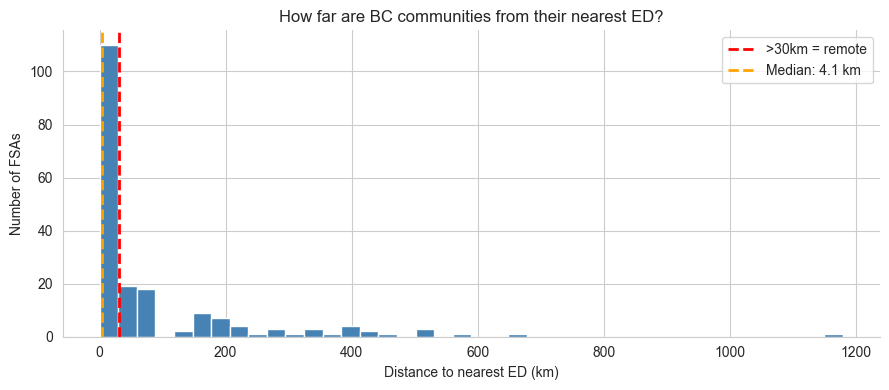

count     191.0
mean       83.1
std       154.6
min         0.0
25%         1.1
50%         4.1
75%        76.0
max      1179.7
Name: min_distance_km, dtype: float64

Over 30km:  79 FSAs
Over 100km: 44 FSAs
Over 300km: 18 FSAs


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(master['min_distance_km'].dropna(), bins=40, color='steelblue', edgecolor='white')
ax.axvline(30, color='red', ls='--', lw=2, label='>30km = remote')
ax.axvline(master['min_distance_km'].median(), color='orange', ls='--', lw=2,
           label=f'Median: {master["min_distance_km"].median():.1f} km')

ax.set_xlabel('Distance to nearest ED (km)')
ax.set_ylabel('Number of FSAs')
ax.set_title('How far are BC communities from their nearest ED?')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS + 'loc_01_distance_hist.png', dpi=150, bbox_inches='tight')
plt.show()

print(master['min_distance_km'].describe().round(1))
print(f'\nOver 30km:  {(master["min_distance_km"] > 30).sum()} FSAs')
print(f'Over 100km: {(master["min_distance_km"] > 100).sum()} FSAs')
print(f'Over 300km: {(master["min_distance_km"] > 300).sum()} FSAs')

**Analysis:** The distribution is extremely skewed. Most urban FSAs are within 5km,
but a meaningful number are 100, 300, or even 1,000+ km away. This split between
urban and rural BC is the defining feature of healthcare access in this province.

### 4b. The most isolated communities

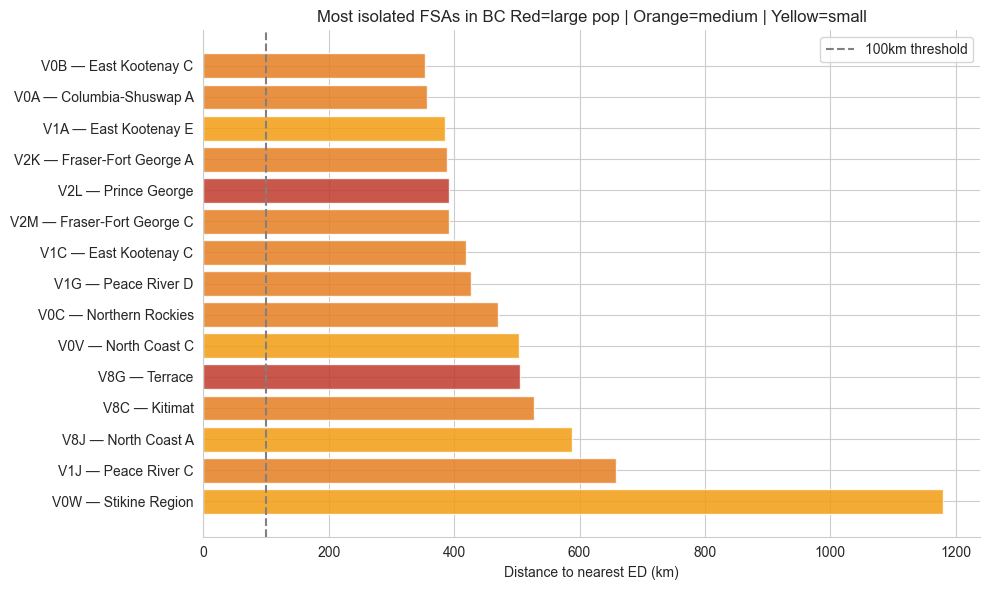

In [6]:
top_far = master.nlargest(15, 'min_distance_km')

fig, ax = plt.subplots(figsize=(10, 6))

# Colour by population size
colours = ['#c0392b' if p > 10000 else '#e67e22' if p > 3000 else '#f39c12'
           for p in top_far['population'].fillna(0)]

ax.barh(top_far['CFSAUID'] + ' — ' + top_far['CSDNAME'].str[:20],
        top_far['min_distance_km'], color=colours, alpha=0.85)
ax.axvline(100, color='gray', ls='--', lw=1.5, label='100km threshold')
ax.set_xlabel('Distance to nearest ED (km)')
ax.set_title('Most isolated FSAs in BC Red=large pop | Orange=medium | Yellow=small')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS + 'loc_02_isolated.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:** Stikine Region (V0W) is 1,180km from the nearest ED — essentially the
whole province away. Prince George (V2L) stands out: 76,000 people and 392km away.
The colour matters — a large red bar is a much bigger public health problem than
a small yellow one at the same distance.

### 4c. Distance matrix — do communities have any options?

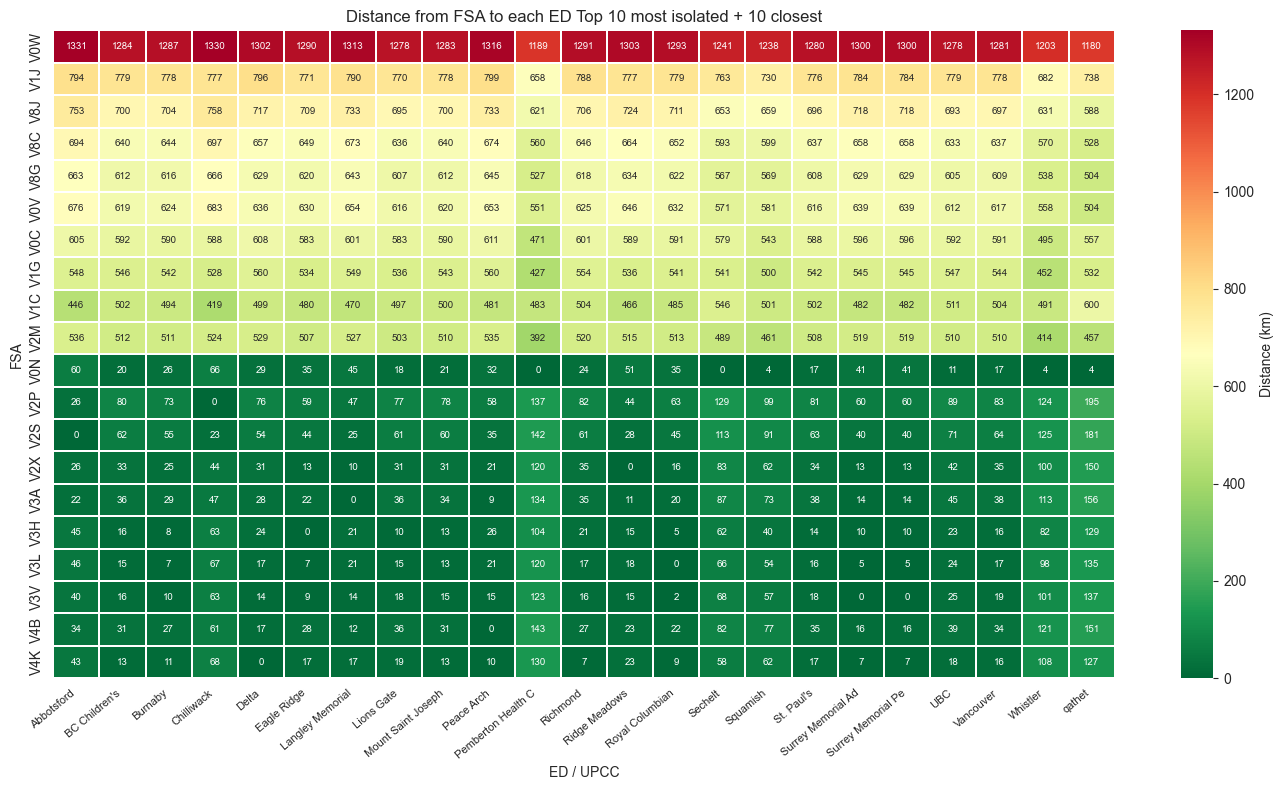

In [7]:
# Pivot distance data into a matrix (FSA rows, ED columns)
dist_matrix = fsa_dist.pivot_table(
    index='FSA', columns='ed_name', values='distance_km', aggfunc='mean'
)

# Select 10 most isolated + 10 closest FSAs
far_fsas   = fsa_nearest.nlargest(10, 'min_distance_km')['FSA'].tolist()
close_fsas = fsa_nearest.nsmallest(10, 'min_distance_km')['FSA'].tolist()
selected   = [f for f in far_fsas + close_fsas if f in dist_matrix.index]

subset = dist_matrix.loc[selected]

# Shorten column names
subset.columns = [c.replace(' Hospital','').replace(' Health Care Centre','')
                   .replace(' General','').replace(' Regional','')[:18]
                  for c in subset.columns]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(subset, cmap='RdYlGn_r', annot=True, fmt='.0f',
            annot_kws={'size': 7}, linewidths=0.2, ax=ax,
            cbar_kws={'label': 'Distance (km)'})
ax.set_xlabel('ED / UPCC')
ax.set_ylabel('FSA')
ax.set_title('Distance from FSA to each ED Top 10 most isolated + 10 closest')
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS + 'loc_03_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:** The top half (isolated FSAs) is almost entirely red — every ED is
hundreds of kilometres away. The bottom half (urban FSAs) is almost entirely green —
they have multiple nearby options. This contrast tells the geographic inequality
story of BC healthcare in one chart.

### 4d. Gap analysis — nearest vs 2nd nearest ED

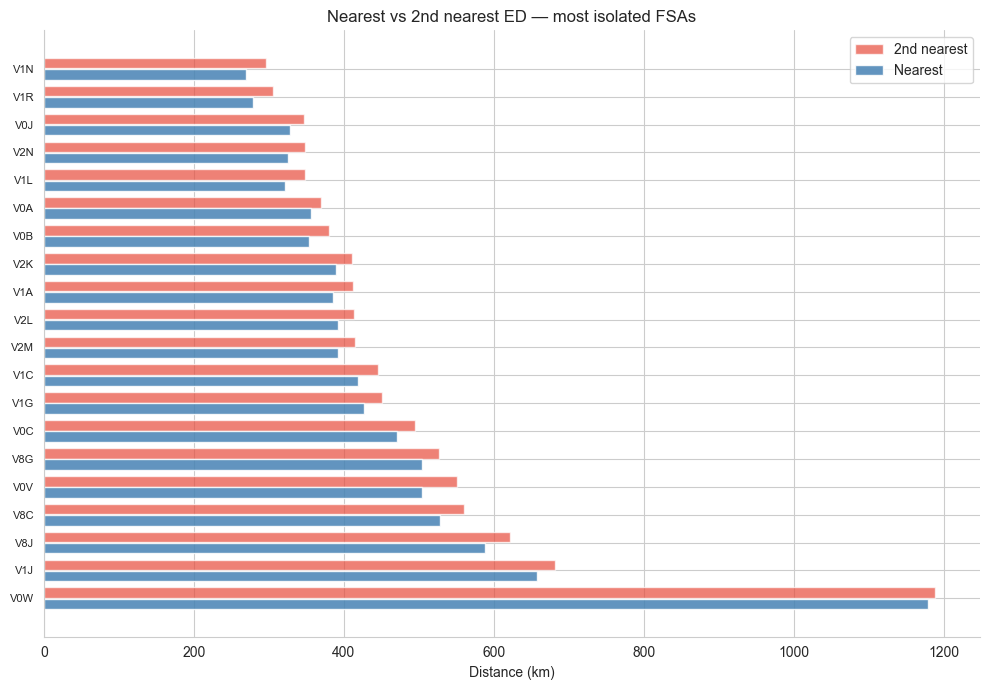

Largest gap between 1st and 2nd nearest ED:
FSA              nearest_ed  min_distance_km  second_km  gap
V9W qathet General Hospital             49.8      116.7 66.8
V9H qathet General Hospital             42.8      107.8 64.9
V9J qathet General Hospital             31.5       89.4 57.9
V9M qathet General Hospital             29.4       83.9 54.5
V0P qathet General Hospital             30.0       84.5 54.5
V0T qathet General Hospital            210.2      259.4 49.1
V0V qathet General Hospital            503.8      551.0 47.2
V8A qathet General Hospital              0.0       43.0 43.0


In [8]:
# Find the 2nd nearest ED per FSA
ranked = fsa_dist.sort_values(['FSA', 'distance_km'])
second = ranked.groupby('FSA').nth(1).reset_index()[['FSA', 'distance_km']]
second.columns = ['FSA', 'second_km']

gap = fsa_nearest.merge(second, on='FSA', how='left')
gap['gap'] = gap['second_km'] - gap['min_distance_km']

top20 = gap.nlargest(20, 'second_km')

fig, ax = plt.subplots(figsize=(10, 7))
y = np.arange(len(top20))
ax.barh(y + 0.2, top20['second_km'],        0.38, label='2nd nearest', color='#e74c3c', alpha=0.7)
ax.barh(y - 0.2, top20['min_distance_km'],  0.38, label='Nearest',     color='steelblue', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(top20['FSA'], fontsize=8)
ax.set_xlabel('Distance (km)')
ax.set_title('Nearest vs 2nd nearest ED — most isolated FSAs')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS + 'loc_04_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Largest gap between 1st and 2nd nearest ED:')
print(gap.nlargest(8, 'gap')[['FSA', 'nearest_ed', 'min_distance_km', 'second_km', 'gap']].round(1).to_string(index=False))

**Analysis:** The gap tells us whether a community has a backup option.
A small gap means patients can divert if one ED is overwhelmed.
A large gap means they are locked to one facility — if it goes down, there is
nowhere to go. FSAs where both bars are very long face a medical emergency
transport problem regardless of which direction they travel.

## 5. Physician Access

### 5a. Physician availability distribution

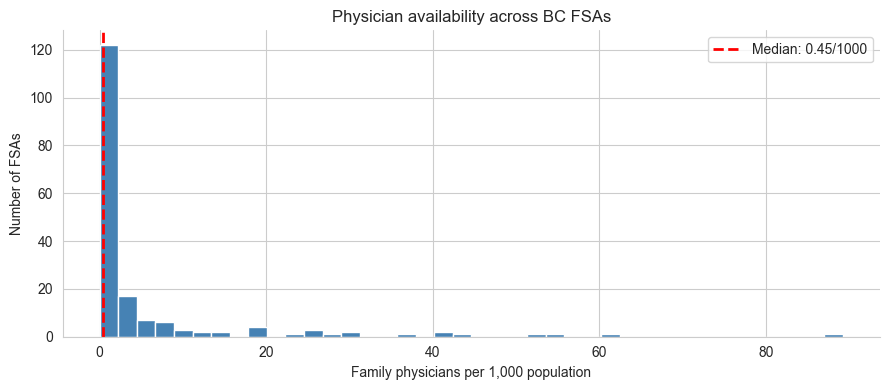

count    178.000
mean       5.401
std       12.450
min        0.005
25%        0.079
50%        0.450
75%        3.685
max       89.258
Name: phys_per_1000, dtype: float64

FSAs with <0.5 physicians per 1,000: 92


In [9]:
phys = master.dropna(subset=['phys_per_1000', 'population'])
phys = phys[phys['population'] > 500]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(phys['phys_per_1000'], bins=40, color='steelblue', edgecolor='white')
ax.axvline(phys['phys_per_1000'].median(), color='red', ls='--', lw=2,
           label=f'Median: {phys["phys_per_1000"].median():.2f}/1000')
ax.set_xlabel('Family physicians per 1,000 population')
ax.set_ylabel('Number of FSAs')
ax.set_title('Physician availability across BC FSAs')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS + 'loc_05_physicians.png', dpi=150, bbox_inches='tight')
plt.show()

print(phys['phys_per_1000'].describe().round(3))
print(f'\nFSAs with <0.5 physicians per 1,000: {(phys["phys_per_1000"] < 0.5).sum()}')

**Analysis:** Physician availability is very unequal. Many FSAs have near-zero
family doctors per 1,000 residents. These communities are more likely to use EDs
for primary care, driving up wait times system-wide.

### 5b. Are areas far from EDs also short on doctors?

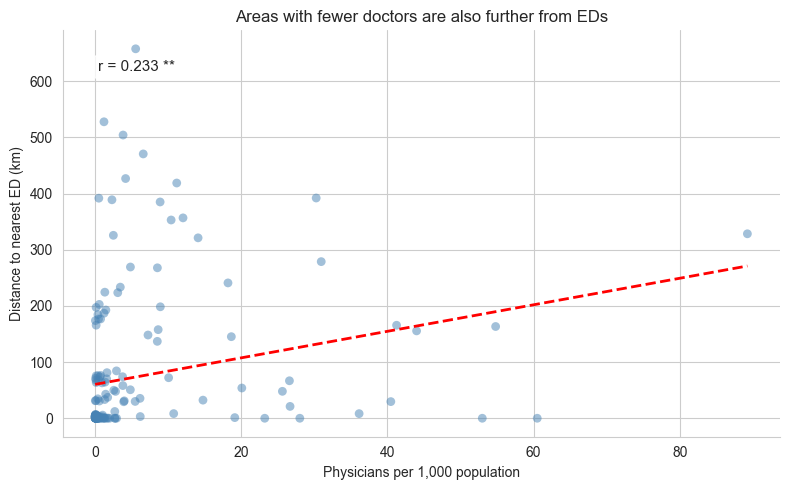

r = 0.233, p = 0.0018


In [10]:
from scipy import stats

sub = master.dropna(subset=['phys_per_1000', 'min_distance_km', 'population'])
sub = sub[sub['population'] > 500]

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sub['phys_per_1000'], sub['min_distance_km'],
           alpha=0.5, s=40, color='steelblue', edgecolors='none')

m, b, r, p, _ = stats.linregress(sub['phys_per_1000'], sub['min_distance_km'])
x_line = np.linspace(sub['phys_per_1000'].min(), sub['phys_per_1000'].max(), 100)
ax.plot(x_line, m*x_line + b, color='red', lw=2, ls='--')

sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
ax.text(0.05, 0.90, f'r = {r:.3f} {sig}', transform=ax.transAxes, fontsize=11,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set_xlabel('Physicians per 1,000 population')
ax.set_ylabel('Distance to nearest ED (km)')
ax.set_title('Areas with fewer doctors are also further from EDs')
plt.tight_layout()
plt.savefig(RESULTS + 'loc_06_phys_vs_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'r = {r:.3f}, p = {p:.4f}')

**Analysis:** The positive correlation confirms rural BC faces a compounding disadvantage —
far from EDs AND short on family doctors. A new ED there would address both problems
simultaneously by reducing ED wait times and providing an access point for people with no GP.

## 6. Building the Underserved Score

### 6a. Normalise each dimension 0–1

In [11]:
def norm(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-9)

loc = master.dropna(subset=['min_distance_km', 'population']).copy()
loc = loc[loc['population'] > 0]

loc['s_dist']  = norm(loc['min_distance_km'])
loc['s_pop']   = norm(loc['population'])
loc['s_poor']  = norm(loc['low_income_pct'].fillna(loc['low_income_pct'].median()))
loc['s_old']   = norm(loc['seniors_pct'].fillna(0))
loc['s_phys']  = norm(loc['pop_per_phys'].clip(upper=loc['pop_per_phys'].quantile(0.95)))

loc['score'] = (
    0.35 * loc['s_dist'] +
    0.25 * loc['s_pop']  +
    0.20 * loc['s_poor'] +
    0.10 * loc['s_old']  +
    0.10 * loc['s_phys']
)

print('Scores built for', len(loc), 'FSAs')
print()
print('Top 10 most underserved:')
print(loc.nlargest(10, 'score')
      [['CFSAUID', 'CSDNAME', 'min_distance_km', 'population', 'low_income_pct', 'score']]
      .round(2).to_string(index=False))

Scores built for 189 FSAs

Top 10 most underserved:
CFSAUID        CSDNAME  min_distance_km  population  low_income_pct  score
    V0W Stikine Region          1179.70       424.0            14.8   0.50
    V6N      Vancouver             2.40    662248.0            13.2   0.44
    V5K      Vancouver             2.28    662248.0            13.2   0.44
    V6L      Vancouver             0.62    662248.0            13.2   0.44
    V5Y      Vancouver             0.56    662248.0            13.2   0.44
    V5M      Vancouver             0.60    662248.0            13.2   0.42
    V5S      Vancouver             2.34    662248.0            13.2   0.41
    V6S      Vancouver             0.96    662248.0            13.2   0.39
    V6G      Vancouver             0.62    662248.0            13.2   0.38
    V5X      Vancouver             2.15    662248.0            13.2   0.38


**How the score works:** Distance gets the highest weight (35%) because physical access
is the most direct barrier. Population (25%) means we prioritise places where many people
would benefit. Low income (20%) adds the equity dimension. Seniors (10%) and physician gap (10%)
complete the picture.

### 6b. Top 10 recommended locations

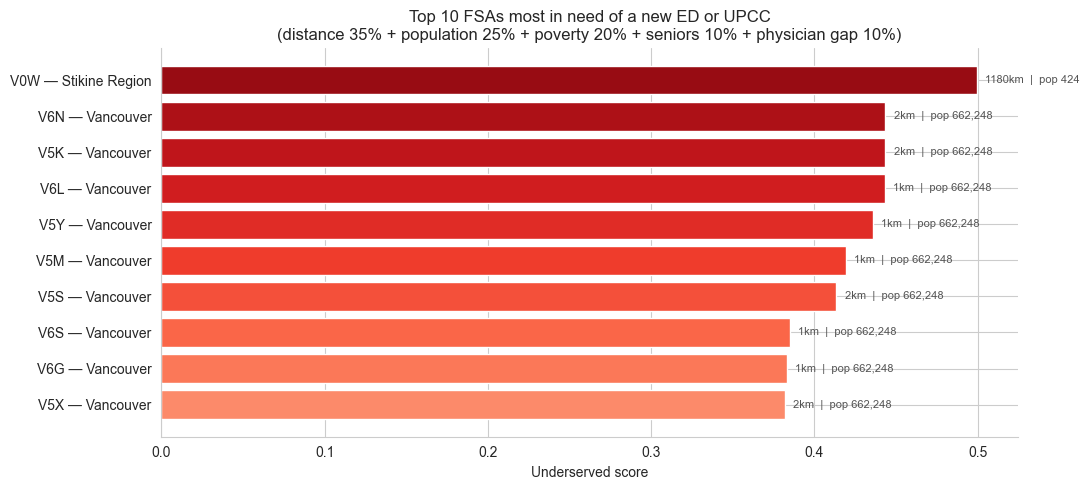

In [14]:
top10 = loc.nlargest(10, 'score').sort_values('score')

fig, ax = plt.subplots(figsize=(11, 5))
colours = plt.cm.Reds(np.linspace(0.4, 0.9, len(top10)))
bars    = ax.barh(top10['CFSAUID'] + ' — ' + top10['CSDNAME'].str[:18],
                  top10['score'], color=colours)

for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{row['min_distance_km']:.0f}km  |  pop {int(row['population']):,}",
            va='center', fontsize=8, color='#555')

ax.set_xlabel('Underserved score')
ax.set_title('Top 10 FSAs most in need of a new ED or UPCC\n'
             '(distance 35% + population 25% + poverty 20% + seniors 10% + physician gap 10%)')
plt.tight_layout()
plt.savefig(RESULTS + 'loc_07_top10.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:** The results split into two types. Stikine Region (V0W) scores high purely
from distance (1,180km) but has tiny population. Vancouver FSAs score high from population
and physician scarcity — they are physically close to EDs but the existing ones are overwhelmed.
These are two completely different problems requiring different solutions.

### 6c. What is driving each FSA's score?

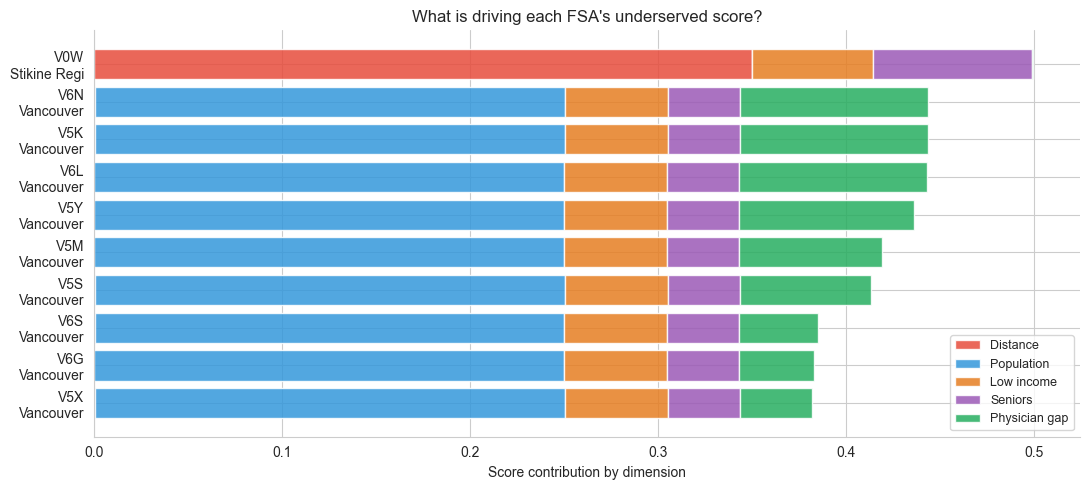

CFSAUID        CSDNAME  score main_driver
    V5X      Vancouver  0.382  Population
    V6G      Vancouver  0.383  Population
    V6S      Vancouver  0.385  Population
    V5S      Vancouver  0.414  Population
    V5M      Vancouver  0.419  Population
    V5Y      Vancouver  0.436  Population
    V6L      Vancouver  0.443  Population
    V5K      Vancouver  0.443  Population
    V6N      Vancouver  0.443  Population
    V0W Stikine Region  0.500    Distance


In [16]:
top10_s = loc.nlargest(10, 'score').sort_values('score')

# Weighted contribution of each dimension
top10_s['c_dist'] = 0.35 * top10_s['s_dist']
top10_s['c_pop']  = 0.25 * top10_s['s_pop']
top10_s['c_poor'] = 0.20 * top10_s['s_poor']
top10_s['c_old']  = 0.10 * top10_s['s_old']
top10_s['c_phys'] = 0.10 * top10_s['s_phys']

labels = top10_s['CFSAUID'] + '\n' + top10_s['CSDNAME'].str[:12]
dims    = ['c_dist', 'c_pop', 'c_poor', 'c_old', 'c_phys']
names   = ['Distance', 'Population', 'Low income', 'Seniors', 'Physician gap']
colours = ['#e74c3c', '#3498db', '#e67e22', '#9b59b6', '#27ae60']

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top10_s))

for dim, name, colour in zip(dims, names, colours):
    ax.barh(labels, top10_s[dim].values, left=bottom,
            label=name, color=colour, alpha=0.85, edgecolor='white')
    bottom += top10_s[dim].values

ax.set_xlabel('Score contribution by dimension')
ax.set_title("What is driving each FSA's underserved score?")
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS + 'loc_08_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

# What is the main driver for each FSA?
driver_map = dict(zip(dims, names))
top10_s['main_driver'] = top10_s[dims].idxmax(axis=1).map(driver_map)
print(top10_s[['CFSAUID', 'CSDNAME', 'score', 'main_driver']].round(3).to_string(index=False))

**Analysis:** Stikine Region is almost entirely red (distance). Vancouver FSAs are
almost entirely blue (population). This stacked bar makes the recommendation honest —
there is no single best location. The answer depends entirely on whether you are
trying to solve geographic access or capacity. Policymakers need to decide that
before picking a location.

### 6d. Distance vs poverty — where are both problems worst?

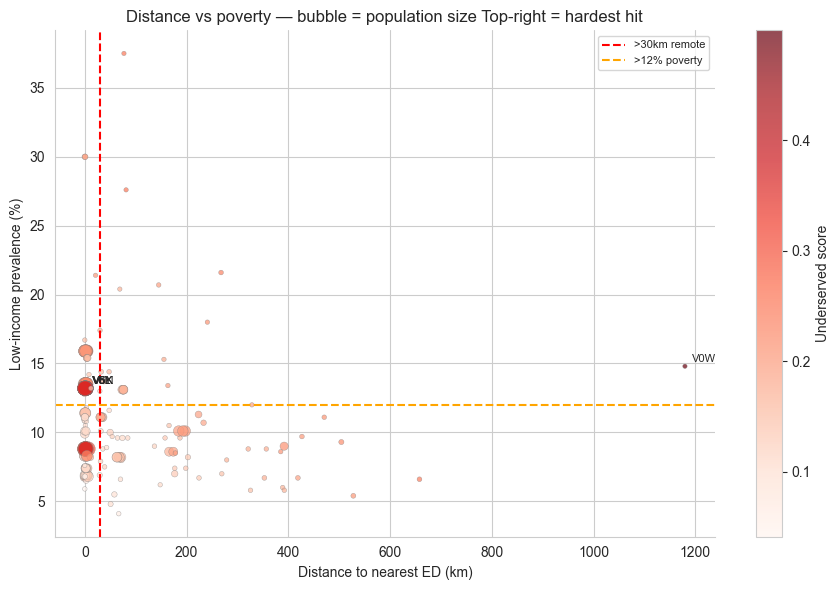

In [15]:
plot_df = loc.dropna(subset=['low_income_pct'])

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    plot_df['min_distance_km'],
    plot_df['low_income_pct'],
    s   = plot_df['population'].clip(upper=300000) / 3000 + 10,
    c   = plot_df['score'],
    cmap= 'Reds', alpha=0.7, edgecolors='gray', lw=0.3
)
plt.colorbar(sc, ax=ax, label='Underserved score')

ax.axvline(30, color='red',    ls='--', lw=1.5, label='>30km remote')
ax.axhline(12, color='orange', ls='--', lw=1.5, label='>12% poverty')

# Label top 5
for _, row in loc.nlargest(5, 'score').iterrows():
    if pd.notna(row.get('low_income_pct')):
        ax.annotate(row['CFSAUID'],
                    (row['min_distance_km'], row['low_income_pct']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.set_xlabel('Distance to nearest ED (km)')
ax.set_ylabel('Low-income prevalence (%)')
ax.set_title('Distance vs poverty — bubble = population size Top-right = hardest hit')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS + 'loc_09_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Analysis:** Top-right quadrant — far from an ED AND high poverty — is where
both barriers compound each other. These communities cannot easily travel to an ED
and also lack the resources to absorb the cost of doing so.
These are the strongest candidates for a new ED from a pure equity standpoint.

## 7. Save Processed Data

In [17]:
# Save master FSA dataset
save_cols = ['CFSAUID', 'CSDNAME', 'population', 'pop_density', 'is_rural',
             'min_distance_km', 'nearest_ed', 'total_physicians', 'phys_per_1000',
             'pop_per_phys', 'low_income_pct', 'seniors_pct', 'median_income']
master[[c for c in save_cols if c in master.columns]].to_csv(
    PROCESSED + 'master_fsa_sociodem.csv', index=False)

# Save location scores
loc[['CFSAUID', 'CSDNAME', 'min_distance_km', 'population', 'low_income_pct',
     'phys_per_1000', 's_dist', 's_pop', 's_poor', 's_old', 's_phys', 'score']]    .sort_values('score', ascending=False)    .to_csv(PROCESSED + 'q3_location_scores.csv', index=False)

print('Saved to data/processed/:')
for f in os.listdir(PROCESSED):
    print(f'  {f}')

Saved to data/processed/:
  q3_location_scores.csv
  master_fsa_sociodem.csv
  wait_times_features.csv


## Summary

- **15+ FSAs are more than 100km** from any ED — Stikine Region is 1,180km away
- **Prince George (V2L):** 76,000 people, 392km away — strongest rural case
- **Terrace and Kitimat** also combine large populations with extreme distances
- Areas far from EDs **also have fewer family doctors** — a compounding problem
- Urban Vancouver FSAs need **capacity expansion**, not a new location
- Two distinct types of underservice: **rural geography** vs **urban capacity**